In [1]:
import os
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from config import *

# FEA_DIR = "/Users/timberzhang/Documents/Documents/2024-JustWatch/OutputRecord/GreedyNonScale"
FEA_DIR = "/Users/timberzhang/Documents/Project/2024-JustWatch/IJHCS/OutputRecord/20250506"
NUM_CLASSES=2
# VIDEO_TYPES=["w", "1", "N_L"]
# VIDEO_TYPES=["w", "1", "R_S", "A_S"]
# VIDEO_TYPES=["p", "1", "N_L"]
# VIDEO_TYPES=["p", "1", "R_S"]
drop_p = [
    "24090917_AD",
	"24092002_AD",
	"24092009_AD",
	"24090308_AD",
	"24091022_AD",
	"24090310_AD",
	"24092209_AD",
	"24092207_AD",
	"24092111_AD",
	"24092102_AD",
	"24092110_AD",
	"24082803_AD",
	"24090412_AD",
]

# Prepare Data

In [2]:
people_list = os.listdir(FEA_DIR)
people_list = list(filter(lambda x: "." not in x, people_list))
len(people_list)

79

In [3]:
people_fea = {}
for _p in people_list:
    if _p in drop_p: continue
    try:
        people_fea[_p] = pd.read_csv(os.path.join(f"{FEA_DIR}/{_p}", "featuresNew.csv"), index_col=0)
    except:
        people_fea[_p] = pd.read_csv(os.path.join(f"{FEA_DIR}/{_p}", "features.csv"), index_col=0)


In [4]:
people_stat = pd.read_excel(os.path.join(DATA_DIR, "ParticipantsInfo.xlsx"), )
people_stat["drop"] = people_stat["PicoFile"].map(lambda x: x in drop_p)
people_stat.drop(people_stat[people_stat["drop"]].index, inplace = True)
print(people_stat.shape)

(60, 19)


In [5]:
# whole_fea_list = ["MatchRoundRatio",]
# whole_fea_list = ["Player1AttentionRatio","Player2AttentionRatio","Player1MinToCircle","Player2MinToCircle","MatchRoundRatio",]
# saccade_fea_list = ["SaccadeSpeed_Mean","SaccadeSpeed_Max","SaccadeSpeed_Std","SaccadeAngel_Mean","SaccadeAngel_Max","SaccadeAngel_Std","SaccadeDelay","SaccadeDelayPercent","TrajectoryDTW"]
fea_list = ["MatchRoundRatio","SaccadeSpeed_Mean","SaccadeSpeed_Max","SaccadeSpeed_Std","Amplitude","UnitAmplitude","SaccadeDelay","SaccadeDelayPercent","TrajDTW","TrajDTWPerBallMove","TrajDTWPerEyeMove","DirecAngle"]

In [6]:
def StatsFeatures(all_people_fea:dict, all_people_stat:pd.DataFrame, fea_list:list, session:list=[0], ball:str="p", number:str="all", stimul_type:str="all" ,twice=0, num_classes=3):
    assert (number in ["f", "b", "all"]), "input number like \"f\" first 2, \"b\" last 2, \"all\" all number"
    if num_classes==3:
        diag_map ={
            "HC" : 0,
            "MCI" : 1,
            "mildAD" : 2,
            "moderateAD" : 2,
            "MMD" : 2,
        }
    else:
        diag_map ={
            "HC" : 0,
            "MCI" : 1,
            "mildAD" : 1,
            "moderateAD" : 1,
            "MMD" : 1,
        } 

    res={}
    for _p in all_people_fea.keys():
        video_list = list(filter(lambda x:x.startswith(ball), all_people_fea[_p].index))

        _session_list = []
        for _v_s in session:
            _v_ids = list(filter(lambda x: x.split("-")[0].split("_")[-3]==str(_v_s), all_people_fea[_p].index))
            _session_list = list(set(_session_list).union(set(_v_ids)))
        video_list = list(set(video_list).intersection(set(_session_list)))

        _number_list = []
        if number=="f":
            _number_list = list(filter(lambda x: (x.split("-")[0].split("_")[-2]=="0") or (x.split("-")[0].split("_")[-2]=="1"), all_people_fea[_p].index))
        elif number=="b":
            _number_list = list(filter(lambda x: (x.split("-")[0].split("_")[-2]=="2") or (x.split("-")[0].split("_")[-2]=="3"), all_people_fea[_p].index))
        else:
            _number_list = video_list
        video_list = list(set(video_list).intersection(set(_number_list)))

        _stimul_list = []
        if stimul_type=="r":
            _stimul_list = list(filter(lambda x: ("R_A" in x.split("-")[0]) or ("R_S" in x.split("-")[0]), all_people_fea[_p].index))
        elif stimul_type=="a":
            _stimul_list = list(filter(lambda x: ("A_A" in x.split("-")[0]) or ("A_S" in x.split("-")[0]), all_people_fea[_p].index))
        else:
            _stimul_list = video_list
        video_list = list(set(video_list).intersection(set(_stimul_list)))

        __multi_list = []
        if twice==2:
            __multi_list = list(filter(lambda x: not x.split("-")[0].endswith("_1"), video_list))
        elif twice==1:
            __multi_list = list(filter(lambda x: x.split("-")[0].endswith("_1"), video_list))
        else:
            __multi_list = video_list
        video_list = list(set(video_list).intersection(set(__multi_list)))
            
        # print(_p)
        # print(video_list)
        # print(len(video_list))
        # print(set(["_".join(i.split("_")[:-3]) for i in video_list]))
        # print(len(set(["_".join(i.split("_")[:-3]) for i in video_list])))

        temp_df:pd.DataFrame = all_people_fea[_p].loc[video_list, fea_list]
        mean_val = temp_df.mean(skipna=True)
        mean_val.index = [i+"_Mean" for i in mean_val.index]
        std_val = temp_df.std(skipna=True)
        std_val.index = [i+"_Std" for i in std_val.index]
        max_val = temp_df.max(skipna=True)
        max_val.index = [i+"_Max" for i in max_val.index]
        min_val = temp_df.min(skipna=True)
        min_val.index = [i+"_Min" for i in min_val.index]
        
        try:
            _diag = all_people_stat[all_people_stat["PicoFile"]==_p]["Label"].values[0]
        except:
            continue
        else:
            if not _diag=="-":
                res[_p] = {
                    **mean_val.to_dict(),
                    **std_val.to_dict(),
                    **max_val.to_dict(),
                    **min_val.to_dict(),
                }
                res[_p]["label"] = diag_map[_diag]

    res = pd.DataFrame(res).T.astype(np.float32)
    if num_classes==3:
        res["diag"] = res["label"].map({
            0:"HC",
            1:"MCI",
            2:"MMAD",
        })
    else:
        res["diag"] = res["label"].map({
            0:"HC",
            1:"PS",
        })
        
    return res

In [7]:
# features_df = StatsFeatures(
#         all_people_fea=people_fea,
#         all_people_stat=people_stat,
#         fea_list=fea_list,
#         session=[1],
#         ball="w",
#         number="all",
#         stimul_type="r",
#         twice=0,
#         num_classes=NUM_CLASSES
#     )

In [8]:
features_df = StatsFeatures(
        all_people_fea=people_fea,
        all_people_stat=people_stat,
        fea_list=fea_list,
        session=[0],
        ball="p",
        number="all",
        stimul_type="all",
        twice=0,
        num_classes=NUM_CLASSES
    )

In [9]:
# features_df = features_df[(features_df["label"]==1) | (features_df["label"]==2)]
features_df["diag"].value_counts()
# .iloc[[33,10,19,22], :]


diag
PS    31
HC    29
Name: count, dtype: int64

In [10]:
# StatsFeatures(
#         all_people_fea=people_fea,
#         all_people_stat=people_stat,
#         fea_list=fea_list,
#         session=[0],
#         ball="p",
#         number="f",
#         twice=0,
#         num_classes=NUM_CLASSES
#     )

# Features Statastic

In [11]:
from scipy.stats import shapiro

if_norm = {}
for key in features_df.columns:
    if key=="diag" or key=="label": continue
    SW_test = shapiro(features_df.loc[:,key])[1]
    # print("Group {}'s \tShapiro—Wilk test P-Value: \t{}".format(key,SW_test))
    if_norm[key] = (True if SW_test >0.05 else False)

In [12]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu, wilcoxon, f_oneway, kruskal

def TTest(_input, _col, label_col):
    group1 = _input[_input.loc[:, label_col] == 0].loc[:, _col]
    group2 = _input[_input.loc[:, label_col] == 1].loc[:, _col]
    t_statistic, p_value = ttest_ind(group1, group2)
    return p_value


def UTest(_input, _col, label_col):
    group1 = _input[_input.loc[:, label_col] == 0].loc[:, _col]
    group2 = _input[_input.loc[:, label_col] == 1].loc[:, _col]
    u_statistic, p_value = mannwhitneyu(group1, group2)
    return p_value


def AnovaTest(_input, _col, label_col):
    groups = []
    for i in _input[label_col].unique():
        groups.append(_input[_input.loc[:, label_col] == i].loc[:, _col])
    u_statistic, p_value = f_oneway(*groups)
    return p_value

def KWTest(_input, _col, label_col):
    groups = []
    for i in _input[label_col].unique():
        groups.append(_input[_input.loc[:, label_col] == i].loc[:, _col])

    u_statistic, p_value = kruskal(*groups)
    return p_value

In [13]:
para_pvalue = {}

if features_df["label"].value_counts().shape[0]==2:
    for key in features_df.columns:
        if key=="diag" or key=="label": continue
        if if_norm[key]:
            p_value = TTest(features_df, key, label_col='label')
        else:
            p_value = UTest(features_df, key, label_col='label')
        para_pvalue[key] = {
            "p-value": p_value,
            "if_para": True if p_value <= 0.05 else False
        }
else:
    for key in features_df.columns:
        if key=="diag" or key=="label": continue
        if if_norm[key]:
            p_value = AnovaTest(features_df, key, label_col='label')
        else:
            p_value = KWTest(features_df, key, label_col='label')
        para_pvalue[key] = {
            "p-value": p_value,
            "if_para": True if p_value <= 0.05 else False
        }

In [14]:
from statsmodels.stats.multitest import multipletests

def correct_multitest_p(st_res:pd.DataFrame|dict, method="fdr_bh") -> pd.DataFrame: 

    if type(st_res)==pd.DataFrame:
        pvals = st_res["p-value"]
        keys = st_res.index.to_list()
        reject, pvals_corrected, _, _ = multipletests(pvals, method=method)

    elif type(st_res)==dict:
        pvals = []
        keys = []
        for key, val in st_res.items():
            keys.append(key)
            pvals.append(val["p-value"])
        reject, pvals_corrected, _, _ = multipletests(pvals, method=method)
    else:
        raise Exception("Datatype of Significance Test result does not support.")
    
    return pd.DataFrame({"p-value":pvals_corrected, "if_para":reject}, index=keys).sort_values(by="p-value")


In [15]:

pt_res = correct_multitest_p(para_pvalue)
pt_res[pt_res["if_para"]]

# pt_res = pd.DataFrame(para_pvalue).T.sort_values(by="p-value")
# pt_res[pt_res["if_para"]]

,p-value,if_para


In [16]:
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt

custom_palette = ["#00712D", "#FF9100", "#D5ED9F", "#FFFBE6"]
if not os.path.exists("pics"):
    os.mkdir("pics")

In [17]:
# pass_feas = pt_res[pt_res["if_para"]]
# _ncols = 4 
# _nrows = (pass_feas.shape[0]//_ncols) if (pass_feas.shape[0]%_ncols)==0 else (pass_feas.shape[0]//_ncols)+1

# f, axs = plt.subplots(nrows=_nrows, ncols=_ncols, figsize=(3*_ncols, 4*_nrows))
# for idx, col in enumerate(pass_feas.index):
#     # col = "MatchRoundRatio_Mean"

#     # Set up the matplotlib figure
#     # Draw a violinplot with a narrower bandwidth than the default
#     try:
#         temp_ax = axs[idx//_ncols, idx%_ncols]
#     except:
#         temp_ax = axs[idx%_ncols]

#     sns.violinplot(
#             data=features_df.loc[:, [col, "diag"]], 
#             palette=custom_palette,
#             alpha=0.7,
#             bw_adjust=.5, 
#             cut=1, 
#             linewidth=1, 
#             x="diag", 
#             y=col, 
#             inner="point", 
#             ax=temp_ax
#         )
#     # sns.boxplot(
#     #         data=features_df.loc[:, [col, "diag"]], 
#     #         palette=custom_palette,
#     #         linewidth=1, 
#     #         x="diag", 
#     #         y=col, 
#     #         ax=temp_ax
#     #     )
    
#     temp_ax.set_xlabel("")
#     temp_ax.set_ylabel("")
#     temp_ax.set_title(col)
#     # sns.despine(left=True, bottom=True)
# plt.tight_layout()

# # plt.savefig("pics/sig_features_{}_{}.png".format("_".join(VIDEO_TYPES), NUM_CLASSES), dpi=200)

In [18]:
# pass_feas = pt_res
# _ncols = 6
# _nrows = (pass_feas.shape[0]//_ncols) if (pass_feas.shape[0]%_ncols)==0 else (pass_feas.shape[0]//_ncols)+1

# f, axs = plt.subplots(nrows=_nrows, ncols=_ncols, figsize=(3*_ncols, 4*_nrows))
# for idx, col in enumerate(pass_feas.index):
#     # col = "MatchRoundRatio_Mean"

#     # Set up the matplotlib figure
#     # Draw a violinplot with a narrower bandwidth than the default
#     temp_ax = axs[idx//_ncols, idx%_ncols]
#     sns.violinplot(
#             data=features_df.loc[:, [col, "diag"]], 
#             palette=custom_palette,
#             alpha=0.7,
#             bw_adjust=.5, 
#             cut=1, 
#             linewidth=1, 
#             x="diag", 
#             y=col, 
#             inner="point", 
#             ax=temp_ax
#         )
#     # sns.boxplot(
#     #         data=features_df.loc[:, [col, "diag"]], 
#     #         palette=custom_palette,
#     #         linewidth=1, 
#     #         x="diag", 
#     #         y=col, 
#     #         ax=temp_ax
#     #     )
    
#     temp_ax.set_xlabel("")
#     temp_ax.set_ylabel("")
#     temp_ax.set_title(col)
#     # sns.despine(left=True, bottom=True)
# plt.tight_layout()

# # plt.savefig("pics/features_{}_{}.png".format("_".join(VIDEO_TYPES), NUM_CLASSES), dpi=200)

# Machine Learning

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import RepeatedKFold, RepeatedStratifiedKFold

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, auc, roc_curve
from lightgbm import LGBMClassifier


# data_indices = features_df.index.to_list()
# fea_list = pt_res[pt_res["if_para"]].index.to_list()
fea_list = pt_res.index.to_list()
final_result = {}
scorer = make_scorer(f1_score)

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=20)
X = features_df[fea_list]
y = features_df['label']

In [20]:
features_df['label'].value_counts()

label
1.0    31
0.0    29
Name: count, dtype: int64

## GridSearch

In [21]:
from sklearn.model_selection import GridSearchCV

parameters = {
        'n_estimators':[1,2,3,4,5,10,15,20,30,40,50],
        'max_depth':[3, 5,7,9,11,13,15]
    }
rf = RandomForestClassifier()
clf = GridSearchCV(rf, parameters, cv=rkf, scoring=scorer)
# clf.fit(X, y)
# print(clf.best_params_)
# print(clf.best_score_)

In [22]:
parameters = {
    'n_estimators':[1,2,3,4,5,10,15,20,30,40,50],
    'learning_rate':[0.9,0.8,0.75,0.7,0.6,0.5,0.4,0.3,0.2,0.1]
    }
ada = AdaBoostClassifier()
clf = GridSearchCV(ada, parameters, cv=rkf, scoring=scorer)
# clf.fit(X, y)
# print(clf.best_params_)
# print(clf.best_score_)

In [23]:
parameters = {
    'n_estimators':[1,2,3,4,5,10,15,20,30,40,50],
    'learning_rate':[0.2,0.1,0.05,0.01]
    }
gbt = GradientBoostingClassifier()
clf = GridSearchCV(gbt, parameters, cv=rkf, scoring=scorer)
# clf.fit(X, y)
# print(clf.best_params_)
# print(clf.best_score_)


## Two Classes

In [24]:
if NUM_CLASSES==2:
    final_result['overall'] = {}
    final_result['overall']['acc'] = []
    final_result['overall']['pre'] = []
    final_result['overall']['recall'] = []
    final_result['overall']['f1'] = []
    final_result['overall']['fpr'] = []
    final_result['overall']['tpr'] = []
    final_result['overall']['thresholds'] = []
    final_result['overall']['auc'] = []
    final_result['overall']['test_index'] = []
    final_result['overall']['trues'] = []
    final_result['overall']['preds'] = []
    final_result['overall']['preds_porb'] = []

    for i, (train_index, test_index) in enumerate(rkf.split(X, y)):
        final_result['overall']['test_index'].append(test_index.tolist())

        # cls = RandomForestClassifier(20, max_depth=5)
        cls = RandomForestClassifier(n_estimators=5, max_depth=5)
        # cls = AdaBoostClassifier(n_estimators=5, learning_rate=0.75)
        # cls = SVC(C=0.75, kernel='linear')
        # cls = SVC(C=0.75, kernel='rbf')
        # cls = LGBMClassifier(learning_rate=1, n_estimators=30)
        x_train, y_train = features_df.iloc[train_index][fea_list], features_df.iloc[train_index]['label']
        x_test, y_test = features_df.iloc[test_index][fea_list], features_df.iloc[test_index]['label']
        cls.fit(X=x_train, y=y_train)

        pred = cls.predict(x_test)
        final_result['overall']['acc'].append(accuracy_score(y_test, pred))
        final_result['overall']['pre'].append(precision_score(y_test, pred))
        final_result['overall']['recall'].append(recall_score(y_test, pred))
        final_result['overall']['f1'].append(f1_score(y_test, pred))
        fpr, tpr, thresholds = roc_curve(y_test, pred)
        final_result['overall']['fpr'].append(fpr)
        final_result['overall']['tpr'].append(tpr)
        final_result['overall']['thresholds'].append(thresholds)
        final_result['overall']['auc'].append(auc(fpr, tpr))

        final_result['overall']['trues'].append(y_test.to_list())
        final_result['overall']['preds'].append(pred.tolist())
        final_result['overall']['preds_porb'].append(cls.predict_proba(x_test).tolist())

In [25]:
if NUM_CLASSES==3:

    final_result['overall'] = {}
    final_result['overall']['acc'] = []
    final_result['overall']['micro_pre'] = []
    final_result['overall']['micro_recall'] = []
    final_result['overall']['micro_f1'] = []
    final_result['overall']['macro_pre'] = []
    final_result['overall']['macro_recall'] = []
    final_result['overall']['macro_f1'] = []
    final_result['overall']['test_index'] = []
    final_result['overall']['trues'] = []
    final_result['overall']['preds'] = []
    final_result['overall']['preds_porb'] = []

    for i, (train_index, test_index) in enumerate(rkf.split(X, y)):
        final_result['overall']['test_index'].append(test_index.tolist())

        cls = RandomForestClassifier(n_estimators=30, max_depth=10)
        # cls = AdaBoostClassifier(n_estimators=10, learning_rate=0.8)
        # cls = SVC(C=0.75, kernel='linear')
        # cls = SVC(C=0.75, kernel='rbf')
        x_train, y_train = features_df.iloc[train_index][fea_list], features_df.iloc[train_index]['label']
        x_test, y_test = features_df.iloc[test_index][fea_list], features_df.iloc[test_index]['label']
        cls.fit(X=x_train, y=y_train)

        pred = cls.predict(x_test)
        final_result['overall']['acc'].append(accuracy_score(y_test, pred))
        final_result['overall']['micro_pre'].append(precision_score(y_test, pred, average='micro'))
        final_result['overall']['micro_recall'].append(recall_score(y_test, pred, average='micro'))
        final_result['overall']['micro_f1'].append(f1_score(y_test, pred, average='micro'))
        final_result['overall']['macro_pre'].append(precision_score(y_test, pred, average='macro'))
        final_result['overall']['macro_recall'].append(recall_score(y_test, pred, average='macro'))
        final_result['overall']['macro_f1'].append(f1_score(y_test, pred, average='macro'))

        final_result['overall']['trues'].append(y_test.to_list())
        final_result['overall']['preds'].append(pred.tolist())
        final_result['overall']['preds_porb'].append(cls.predict_proba(x_test).tolist())

In [26]:
for key in final_result['overall'].keys():
    if key in ['fpr', 'tpr', 'thresholds', 'test_index', 'trues', 'preds', 'preds_porb']:
        continue
    print(key, np.mean(final_result['overall'][key]))

acc 0.5541666666666667
pre 0.5721428571428572
recall 0.5816666666666667
f1 0.5628000071823602
auc 0.5556666666666668


In [27]:
errors = []
for idx, test_ids in enumerate(final_result["overall"]["test_index"]):
    _true = final_result["overall"]["trues"][idx]
    _pred = final_result["overall"]["preds"][idx]
    for i, (t, p) in enumerate(zip(_true, _pred)):
        if not t==p:
            errors.append(test_ids[i])
most_error = pd.value_counts(errors).head(7).index.to_list()
pd.value_counts(errors).to_csv("error.csv")

In [28]:
features_df.iloc[[
40,
5,
58,
36,
9,
], :].index

Index(['24082301_AD', '24092211_AD', '24092105_AD', '24091020_AD',
       '24092210_AD'],
      dtype='object')

In [29]:
stat = pd.DataFrame(final_result["overall"])

In [30]:
best_acc=0
best_indices = []
for indices in np.array(stat.index).reshape(-1, 5):
    _acc = stat.iloc[indices.tolist(),:]["acc"].mean()
    if _acc > best_acc:
        best_acc = _acc
        best_indices = indices

In [31]:
final_result["overall"] = stat.iloc[best_indices, :].to_dict('list')

In [32]:
for key in final_result['overall'].keys():
    if key in ['fpr', 'tpr', 'thresholds', 'test_index', 'trues', 'preds', 'preds_porb']:
        continue
    print(key, np.mean(final_result['overall'][key]))

acc 0.6666666666666667
pre 0.7242857142857143
recall 0.6523809523809523
f1 0.6599600399600399
auc 0.6761904761904762


Text(59.5, 0.5, 'Target')

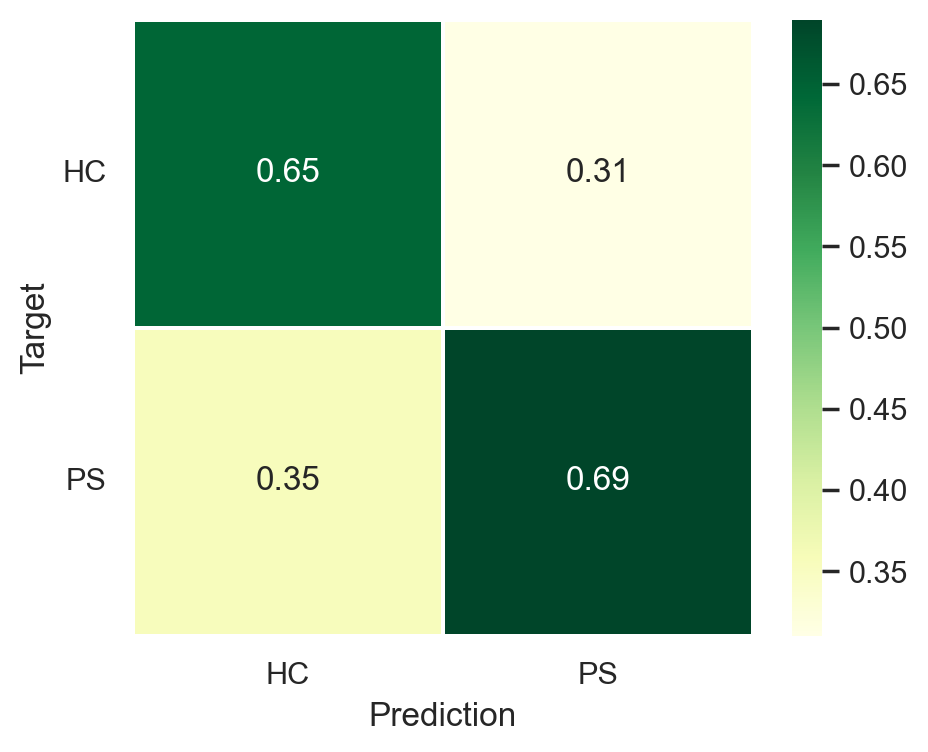

In [33]:
from sklearn.metrics import confusion_matrix

trues = [item for sublist in final_result["overall"]["trues"] for item in sublist]
preds = [item for sublist in final_result["overall"]["preds"] for item in sublist]
if NUM_CLASSES==2:
    preds_prob = [item[1] for sublist in final_result["overall"]["preds_porb"] for item in sublist]
else:
    preds_prob = [item for sublist in final_result["overall"]["preds_porb"] for item in sublist]
f,ax = plt.subplots(figsize=(5,4), dpi=200)
C2 = confusion_matrix(trues, preds, labels=[0,1,2] if NUM_CLASSES==3 else [0,1])
# C2 = C2 / len(trues)
C2 = C2 / C2.sum(axis=0)

sns.heatmap(C2, annot=True, ax=ax, cmap="YlGn", linewidth=.8) 

if NUM_CLASSES==3:
    ax.set_yticklabels(['HC', 'MCI', 'Mild-AD'])
    ax.set_xticklabels(['HC', 'MCI', 'Mild-AD'])
else:
    ax.set_yticklabels(['HC', 'PS'])
    ax.set_xticklabels(['HC', 'PS'])

plt.setp(ax.get_yticklabels(), rotation=0)
ax.set_xlabel('Prediction')
ax.set_ylabel('Target')

In [34]:
from sklearn.metrics import roc_auc_score
if NUM_CLASSES==3:
    print("Macro One-vs-Rest AUC", roc_auc_score(trues, preds_prob, multi_class="ovr", average="macro"))
    print("Weighted One-vs-Rest AUC", roc_auc_score(trues, preds_prob, multi_class="ovr", average="weighted"))
    print("Macro One-vs-One AUC", roc_auc_score(trues, preds_prob, multi_class="ovo", average="macro"))
    print("Weighted One-vs-One AUC", roc_auc_score(trues, preds_prob, multi_class="ovo", average="weighted"))
else:
    print("AUC", roc_auc_score(trues, preds_prob))

AUC 0.6718576195773082


In [35]:
trues_np = np.array(trues, dtype=np.int16)
trues_onehot = np.zeros((trues_np.size, trues_np.max() + 1))
trues_onehot[np.arange(trues_np.size), trues_np] = 1

preds_np = np.array(preds, dtype=np.int16)
preds_onehot = np.zeros((preds_np.size, preds_np.max() + 1))
preds_onehot[np.arange(preds_np.size), preds_np] = 1

preds_prob_np = np.array(preds_prob)

In [36]:
from itertools import cycle
lw = 2

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(trues_onehot[:, i], preds_prob_np[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(trues_onehot.ravel(), preds_prob_np.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= NUM_CLASSES

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(figsize=(9,9), dpi=200)
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc["macro"]),
    color="navy",
    linestyle=":",
    linewidth=4,
)

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=lw,
        label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Some extension of Receiver operating characteristic to multiclass")
plt.legend(loc="lower right")
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed